# 1. Pandas basics: a table with meaning

Learn to construct and inspect a DataFrame, select rows and columns, calculate derived values, group records, and merge a lookup table safely. Prerequisite: [NumPy basics](../../../01_Python_Foundations/13_numpy_basics.ipynb). You should recognize arrays, shapes, and simple function calls. Allow two hours, including checking a small sales report manually.

## 2. What problem does this solve?

Real datasets contain names, dates, identifiers, categories, and numbers together. A numerical array alone does not explain which column means quantity. pandas supplies a **DataFrame**, a labeled table, and a **Series**, a labeled one-dimensional collection. Labels make many operations readable, but they also introduce automatic alignment that must be understood.

The first task is to identify what a row means. Is it one customer, one order, or one item within an order? Totals and joins can be wrong even when every cell is a valid number if the unit of observation is misunderstood.

## 3. Intuition and analogy

Imagine an organized ledger. Each row records one sale line. Column headings tell you whether a number is an order identifier, a quantity, or a price. A separate product list records the price of each product. Joining the two tables resembles looking up each line's product in that reference list.

If the product list accidentally has two prices for the same product, looking up one sale can create two rows. This is why table operations need rules about keys, not just convenient syntax.

## 4. Terminology

An **index** labels rows. It need not equal row position. `.loc` selects by labels; `.iloc` selects by integer positions. A **Boolean mask** is one true-or-false value per row. **Grouping** separates rows by a key before computing summaries. **Aggregation** reduces each group to a statistic such as a sum.

A **key** identifies the entity used in a join. A **many-to-one merge** means many sale rows may match one product row. A **missing value** represents absent information; it is not automatically zero. **Schema** refers to expected columns, types, and constraints. DataFrames can hold different types in different columns.

## 5. Mathematical foundations

For sale line $i$, let $q_i$ be quantity in items and $p_i$ be price in currency units per item. Revenue is $r_i=q_i p_i$, in currency units. Total revenue for product group $g$ is

$$R_g=\sum_{i:\,product_i=g} r_i.$$

The notation under the sum means include only rows whose product equals $g$. Each input column has one value per row, so quantity and price vectors both have shape $(n,)$. Elementwise multiplication creates another length-$n$ column. Grouping reduces many rows to one result per product.

## 6. Hand-calculated example

Four sales have products A, B, A, B and quantities 2, 1, 3, 4. Product A costs ten units per item; B costs twenty. Line revenues are 20, 20, 30, and 80. A contributes $20+30=50$; B contributes $20+80=100$; total revenue is 150.

These are sales amounts, not profits. No cost or refund information is included. Group names are categories; there is no numerical distance from product A to product B.

## 7. Implementation from scratch

In [1]:
# Enable embedded figures in this fresh notebook kernel.
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')

In [2]:
products = ['A', 'B', 'A', 'B']
quantities = [2, 1, 3, 4]
prices = {'A': 10, 'B': 20}
totals = {}
for product, quantity in zip(products, quantities):
    line_revenue = quantity * prices[product]
    totals[product] = totals.get(product, 0) + line_revenue
print('Revenue by product:', totals)
assert totals == {'A': 50, 'B': 100}

Revenue by product: {'A': 50, 'B': 100}


The dictionary `prices` maps a product name to its price. `totals.get(product,0)` returns the previous accumulated amount, or zero before the first sale. The loop makes the grouping mechanism visible before we use pandas to express it directly.

## 8. Step-by-step output inspection

In [3]:
import pandas as pd
from IPython.display import display
sales = pd.DataFrame({'sale_id': [101, 102, 103, 104],
                      'product': products, 'quantity': quantities})
display(sales)
print('Rows and columns:', sales.shape)
print('Column types:\n', sales.dtypes)
assert sales.shape == (4, 3)
assert sales['sale_id'].is_unique

,sale_id,product,quantity
0,101,A,2
1,102,B,1
2,103,A,3
3,104,B,4


Rows and columns: (4, 3)
Column types:
 sale_id     int64
product       str
quantity    int64
dtype: object


`sales['quantity']` is a Series with shape `(4,)`. `sales[['quantity']]` is a DataFrame with shape `(4,1)`. The extra brackets specify a list of selected columns. Inspect `.head()`, `.shape`, `.dtypes`, and missing counts before modeling. An integer identifier should not automatically become a meaningful numerical feature.

## 9. Library implementation

In [4]:
price_table = pd.DataFrame({'product': ['A', 'B'], 'unit_price': [10, 20]})
joined = sales.merge(price_table, on='product', how='left', validate='many_to_one', indicator=True)
assert len(joined) == len(sales)
assert joined['_merge'].eq('both').all()
joined['revenue'] = joined['quantity'] * joined['unit_price']
by_product = joined.groupby('product', sort=True)['revenue'].sum()
assert by_product.to_dict() == totals
assert joined['revenue'].sum() == 150
display(joined)
print(by_product)

,sale_id,product,quantity,unit_price,_merge,revenue
0,101,A,2,10,both,20
1,102,B,1,20,both,20
2,103,A,3,10,both,30
3,104,B,4,20,both,80


product
A     50
B    100
Name: revenue, dtype: int64


`how='left'` preserves sale rows even if a product is missing from the lookup. The merge indicator reveals unmatched rows. `validate='many_to_one'` rejects duplicate lookup keys. These checks protect the meaning of totals; a successful merge without them would not prove correctness.

## 10. Visualization

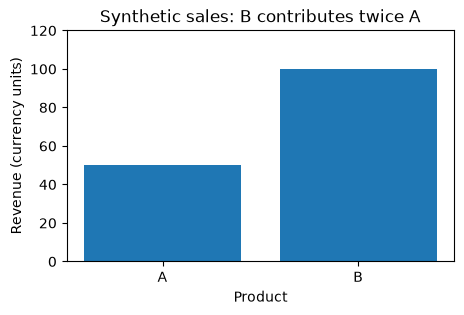

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(by_product.index, by_product.values)
ax.set(xlabel='Product', ylabel='Revenue (currency units)', title='Synthetic sales: B contributes twice A', ylim=(0, 120))
display(fig)
plt.close(fig)

The bar height for B is 100, twice A's 50. That difference combines unit price and quantity; it does not demonstrate that customers prefer B or that B has higher profit. A useful caption explains what the plot cannot establish as well as what it shows.

## 11. Realistic data-quality experiment

This small CSV string mimics a local file without requiring a download. It contains a missing quantity and an exact duplicate. We diagnose them explicitly rather than silently filling or deleting everything.

In [6]:
from io import StringIO
csv_text = 'sale_id,product,quantity\n201,A,2\n202,B,\n201,A,2\n'
raw = pd.read_csv(StringIO(csv_text))
print('Missing values:\n', raw.isna().sum())
print('Exact duplicate rows:', raw.duplicated().sum())
assert raw['quantity'].isna().sum() == 1
assert raw.duplicated().sum() == 1
deduplicated = raw.drop_duplicates().copy()
incomplete = deduplicated.loc[deduplicated['quantity'].isna()]
assert len(incomplete) == 1
display(incomplete)

Missing values:
 sale_id     0
product     0
quantity    1
dtype: int64
Exact duplicate rows: 1


,sale_id,product,quantity
1,202,B,NaN


We can justify removing the repeated record only if it truly represents duplicate recording of the same sale. Two identical purchases might be legitimate separate events if identifiers differ. Missing quantity should be investigated; replacing it with zero would claim no items were sold. If a model later uses imputation, its statistics must be learned on training data only.

## 12. Choices and experiments

Choose join direction, key constraints, grouping keys, and missing-data rules deliberately. These are data-processing choices, not learned model parameters. Change the example price table to contain duplicate A rows and confirm that merge validation raises an error. Do not remove validation merely to make the program finish: resolve the ambiguous business rule.

## 13. Evaluation

Check row count, unique identifiers, unmatched keys, missingness, and totals against hand calculations. Group totals should sum to the same overall revenue when every row belongs to exactly one included group. pandas may exclude missing group keys by default; specify how those should be reported rather than allowing them to vanish unnoticed.

## 14. Assumptions and limitations

We assume prices are constant across these four transactions. Real sales may need the price valid at transaction time, tax rules, currency conversion, and returns. An ordinary product-name merge would then be inadequate. pandas keeps data in memory, so very large tables may require chunking or a database. Convenient syntax cannot correct an incorrectly specified relationship.

## 15. Common mistakes and debugging

Series arithmetic aligns row labels, not just positions. Two equal-length Series with different indices can produce unexpected missing values. Check indices before combining separately filtered objects. Use `.loc[mask,'column'] = value` for explicit assignment; avoid chained indexing whose behavior is harder to reason about. Selecting rows by `.iloc[0]` means first position, while `.loc[0]` means row label zero if that label exists.

## 16. Comparison with alternatives

NumPy is natural for homogeneous numerical arrays; pandas is natural for labeled mixed-type tables. SQL is useful for durable tables, joins, and aggregation inside databases. A dictionary of lists can teach the mechanics, but it lacks pandas' alignment and inspection tools. Each representation has rules worth learning rather than treating conversion as harmless.

## 17. Exercises

1. **Beginner:** Select sales with quantity at least three and predict their sale IDs.
2. **Beginner:** Compute total items sold, distinguishing items from revenue.
3. **Beginner:** Explain the shape difference between one and two pairs of selection brackets.
4. **Intermediate:** Add a sale for unknown product C and describe the checks that reveal its missing price.
5. **Intermediate:** Show why two A rows in the lookup can inflate revenue without validation.
6. **Challenge:** Design a product report with quantity, revenue, and weighted average unit price. Explain why averaging product prices without quantities answers a different question.

## 18. Detailed solutions

1. Quantities three and four belong to sale IDs 103 and 104.
2. $2+1+3+4=10$ items. Revenue is 150 currency units; they cannot be compared as if they share units.
3. A single column label returns a Series `(4,)`; a list containing that label returns a DataFrame `(4,1)`.
4. The left merge retains C, sets price missing, and marks `_merge` as `left_only`. Reject or investigate it before multiplying.
5. Each A sale matches both lookup rows, duplicating its contribution. The many-to-one validation prevents this ambiguity.
6. Divide group revenue by group quantity: A is $50/5=10$, B is $100/5=20$, and overall is $150/10=15$. If quantities differ, an unweighted average of prices ignores how many units were sold.

In [7]:
assert sales.loc[sales['quantity'] >= 3, 'sale_id'].tolist() == [103, 104]
report = joined.groupby('product').agg(items=('quantity', 'sum'), revenue=('revenue', 'sum'))
report['weighted_unit_price'] = report['revenue'] / report['items']
assert report['items'].sum() == 10
assert report.loc['A', 'weighted_unit_price'] == 10
display(report)

,items,revenue,weighted_unit_price
product,,,
A,5,50,10.0
B,5,100,20.0


## 19. Knowledge check

**What is a DataFrame?** A labeled two-dimensional table. **What does `.loc` use?** Labels or aligned Boolean masks. **Is missing zero?** No. **What does groupby do?** Partitions rows before aggregation or another group operation. **Why validate joins?** Key multiplicity can change row counts and numerical meaning.

## 20. Interview preparation

**Series versus array?** A Series carries an index and alignment behavior. **How detect leakage in preprocessing?** Ask whether evaluation information influenced a fitted statistic or choice. **How investigate duplicates?** Define the observation key before deciding which repeated records are invalid. **Why use a left join here?** To retain and diagnose every sale. **How verify an aggregation?** Reconcile counts and totals against input data and independent small calculations.

## 21. Summary and next steps

Tables need semantic rules as well as numerical operations. Continue to [Visualizing data](../../../01_Python_Foundations/18_visualizing_data.ipynb), carrying units, row meaning, and missingness into every chart.